# Base Instruct IP Vector Sanity Check

This notebook evaluates whether **IP steering vectors have directional signal** independent of fine-tuning.

**Setup:** The base instruct model (`Qwen2.5-7B-Instruct`) was given system prompts explicitly eliciting each trait — no fine-tuning involved. IP steering vectors were then applied at inference to check whether they can suppress the negative trait even when the model is directly instructed to exhibit it.

**Three elicitation modes:**
- `neg` — only negative trait elicited (control: isolated suppression)
- `pos` — only positive trait elicited (control: does steering damage positive?)
- `both` — both traits elicited simultaneously (primary test: selective suppression?)

**4 steering configs:** L16/L20 × r512_orth/fixed_raw, all α=8.0 — 8 pairs × 100 queries each.

Suppression in `neg` mode = vectors encode trait directions. Near-zero delta in `pos` mode = orthogonalization works. Both together in `both` mode = selective suppression.

> **Convention:** The <u>negative trait</u> (suppression target) is **underlined** in all figures and tables throughout this notebook.

In [18]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
import torch.nn.functional as F
from scipy import stats
from IPython.display import display, HTML

# Disable mathtext parsing globally — prevents issues with underscores, hyphens,
# and special chars in label strings (e.g. ALL-CAPS, r512_orth).
plt.rcParams.update({"text.usetex": False, "text.parse_math": False})

ROOT = Path("..")
SCORES_DIR  = ROOT / "results/base_instruct_sanity"
TRAIT_DIR   = ROOT / "results/layer_sweep/extraction/trait_activations"
NEUTRAL_PT  = ROOT / "results/layer_sweep/extraction/neutral_activations.pt"
LAYER       = 16   # consistent with Exploration #1 geometry analysis

# ── Steering config display names ────────────────────────────────────────────
CONFIG_ORDER = [
    "L16_r512_orth_a8", "L20_r512_orth_a8",
    "L16_fixed_raw_a8", "L20_fixed_raw_a8",
    "L16_random_a8",    "L20_random_a8",
    "L16_neutral_a8",   "L20_neutral_a8",
]
CONFIG_LABELS = {
    "L16_r512_orth_a8":  "L16 r512-orth",
    "L20_r512_orth_a8":  "L20 r512-orth",
    "L16_fixed_raw_a8":  "L16 fixed-raw",
    "L20_fixed_raw_a8":  "L20 fixed-raw",
    "L16_random_a8":     "L16 random",
    "L20_random_a8":     "L20 random",
    "L16_neutral_a8":    "L16 neutral",
    "L20_neutral_a8":    "L20 neutral",
}
CONFIG_COLORS = {
    "L16_r512_orth_a8": "#4C72B0",
    "L20_r512_orth_a8": "#DD8452",
    "L16_fixed_raw_a8": "#55A868",
    "L20_fixed_raw_a8": "#C44E52",
    "L16_random_a8":    "#9467bd",
    "L20_random_a8":    "#8c564b",
    "L16_neutral_a8":   "#e377c2",
    "L20_neutral_a8":   "#7f7f7f",
}

# ── Pair labels ───────────────────────────────────────────────────────────────
# Plain text for matplotlib (no underscores, no special chars that trigger mathtext).
# Negative trait (suppression target) marked with * in plot labels,
# underlined in HTML tables.
PAIR_LABELS = {
    "monotone_enthusiasm":    "monotone / enthusiasm*",
    "brevity_enthusiasm":     "brevity / enthusiasm*",
    "sarcasm_paranoia":       "sarcasm / paranoia*",
    "informal_assertiveness": "informal / assertiveness*",
    "poetic_mathematical":    "poetic / mathematical*",
    "fanaticism_ALL-CAPS":    "fanaticism / ALL-CAPS*",
    "sarcasm_empathy":        "sarcasm / empathy*",
    "cheater_philosophical":  "cheater / philosophical*",
}

# For HTML tables (CSS underline)
PAIR_LABELS_HTML = {
    "monotone_enthusiasm":    "monotone / <u>enthusiasm</u>",
    "brevity_enthusiasm":     "brevity / <u>enthusiasm</u>",
    "sarcasm_paranoia":       "sarcasm / <u>paranoia</u>",
    "informal_assertiveness": "informal / <u>assertiveness</u>",
    "poetic_mathematical":    "poetic / <u>mathematical</u>",
    "fanaticism_ALL-CAPS":    "fanaticism / <u>ALL-CAPS</u>",
    "sarcasm_empathy":        "sarcasm / <u>empathy</u>",
    "cheater_philosophical":  "cheater / <u>philosophical</u>",
}

# ── Trait vector filenames for geometry (pos_trait, neg_trait) ────────────────
PAIR_TRAIT_FILES = {
    "monotone_enthusiasm":    ("monotone",    "enthusiasm"),
    "brevity_enthusiasm":     ("brevity",     "enthusiasm"),
    "sarcasm_paranoia":       ("sarcasm",     "paranoia"),
    "informal_assertiveness": ("informal",    "assertiveness"),
    "poetic_mathematical":    ("poetic",      "mathematical"),
    "fanaticism_ALL-CAPS":    ("fanaticism",  "ALL-CAPS"),
    "sarcasm_empathy":        ("sarcasm",     "empathy"),
    "cheater_philosophical":  ("cheater",     "philosophy"),   # file is philosophy.pt
}

# ── Data loader ───────────────────────────────────────────────────────────────
def load_scores(scores_dir: Path) -> pd.DataFrame:
    """Load all *_scores.jsonl files under scores_dir into one DataFrame."""
    records = []
    for path in sorted(scores_dir.glob("*/instruction_wild/scores/*_scores.jsonl")):
        with open(path) as f:
            for line in f:
                line = line.strip()
                if line:
                    records.append(json.loads(line))
    df = pd.DataFrame(records)
    def parse_config(name):
        for mode in ("both", "neg", "pos"):
            if name.startswith(mode + "_"):
                return mode, name[len(mode)+1:]
        return None, name
    df[["mode", "steering_cfg"]] = pd.DataFrame(
        df["config_name"].map(parse_config).tolist(), index=df.index
    )
    return df

df = load_scores(SCORES_DIR)
PAIRS = list(PAIR_LABELS.keys())
print(f"Loaded {len(df):,} records | pairs: {df['pair_id'].nunique()} | modes: {sorted(df['mode'].unique())}")
print(f"Steering configs: {sorted(df['steering_cfg'].unique())}")


Loaded 12,085 records | pairs: 8 | modes: ['both', 'neg', 'pos']
Steering configs: ['L16_fixed_raw_a8', 'L16_r512_orth_a8', 'L20_fixed_raw_a8', 'L20_r512_orth_a8', 'baseline']


In [11]:
# ── Elicitation sanity check ─────────────────────────────────────────────────
# Before interpreting any steering results, verify that the simple system prompts
# actually elicited the traits. If baseline scores are low, results for that pair
# are unreliable (nothing to suppress).

baselines = df[df["steering_cfg"] == "baseline"]

rows = []
for pair_id in PAIRS:
    neg_bl = baselines[(baselines["pair_id"] == pair_id) & (baselines["mode"] == "neg")]["neg_score"]
    pos_bl = baselines[(baselines["pair_id"] == pair_id) & (baselines["mode"] == "pos")]["pos_score"]
    neg_ok = len(neg_bl) > 0 and neg_bl.mean() >= 20
    pos_ok = len(pos_bl) > 0 and pos_bl.mean() >= 20
    rows.append({
        "pair_id": pair_id,
        "neg_mean": neg_bl.mean() if len(neg_bl) else float("nan"),
        "neg_std":  neg_bl.std()  if len(neg_bl) else float("nan"),
        "pos_mean": pos_bl.mean() if len(pos_bl) else float("nan"),
        "pos_std":  pos_bl.std()  if len(pos_bl) else float("nan"),
        "neg_ok": neg_ok,
        "pos_ok": pos_ok,
    })

# Render as HTML table with underlined negative trait in pair column
html_rows = ""
for r in rows:
    pair_label = PAIR_LABELS_HTML[r["pair_id"]]
    neg_str = f"{r['neg_mean']:.1f} ± {r['neg_std']:.1f}" if not pd.isna(r["neg_mean"]) else "—"
    pos_str = f"{r['pos_mean']:.1f} ± {r['pos_std']:.1f}" if not pd.isna(r["pos_mean"]) else "—"
    neg_flag = "✓" if r["neg_ok"] else "<span style='color:orange'>⚠ LOW</span>"
    pos_flag = "✓" if r["pos_ok"] else "<span style='color:orange'>⚠ LOW</span>"
    html_rows += f"<tr><td>{pair_label}</td><td>{neg_str}</td><td>{pos_str}</td><td>{neg_flag}</td><td>{pos_flag}</td></tr>\n"

html = f"""
<table style="border-collapse:collapse; font-size:13px">
  <thead>
    <tr style="border-bottom:2px solid #ccc">
      <th style="text-align:left; padding:4px 12px">Pair</th>
      <th style="padding:4px 12px">neg_baseline neg_score</th>
      <th style="padding:4px 12px">pos_baseline pos_score</th>
      <th style="padding:4px 12px">neg OK?</th>
      <th style="padding:4px 12px">pos OK?</th>
    </tr>
  </thead>
  <tbody>
{html_rows}  </tbody>
</table>
<p style="font-size:12px; color:#555; margin-top:6px">
Scores ≥ 20 = trait reliably elicited. ⚠ LOW = system prompt didn't work → steering results for that pair are noisy.<br>
<u>Underlined trait</u> = negative trait (suppression target).
</p>
"""
display(HTML(html))

Pair,neg_baseline neg_score,pos_baseline pos_score,neg OK?,pos OK?
monotone / enthusiasm,64.2 ± 22.8,66.6 ± 25.5,✓,✓
brevity / enthusiasm,64.9 ± 21.8,71.9 ± 23.0,✓,✓
sarcasm / paranoia,30.9 ± 29.0,56.3 ± 30.5,✓,✓
informal / assertiveness,69.7 ± 19.0,68.6 ± 18.7,✓,✓
poetic / mathematical,25.9 ± 31.7,81.3 ± 20.7,✓,✓
fanaticism / ALL-CAPS,93.3 ± 20.3,24.8 ± 27.8,✓,✓
sarcasm / empathy,36.8 ± 29.3,60.2 ± 29.3,✓,✓
cheater / philosophical,51.5 ± 31.2,15.1 ± 29.3,✓,⚠ LOW


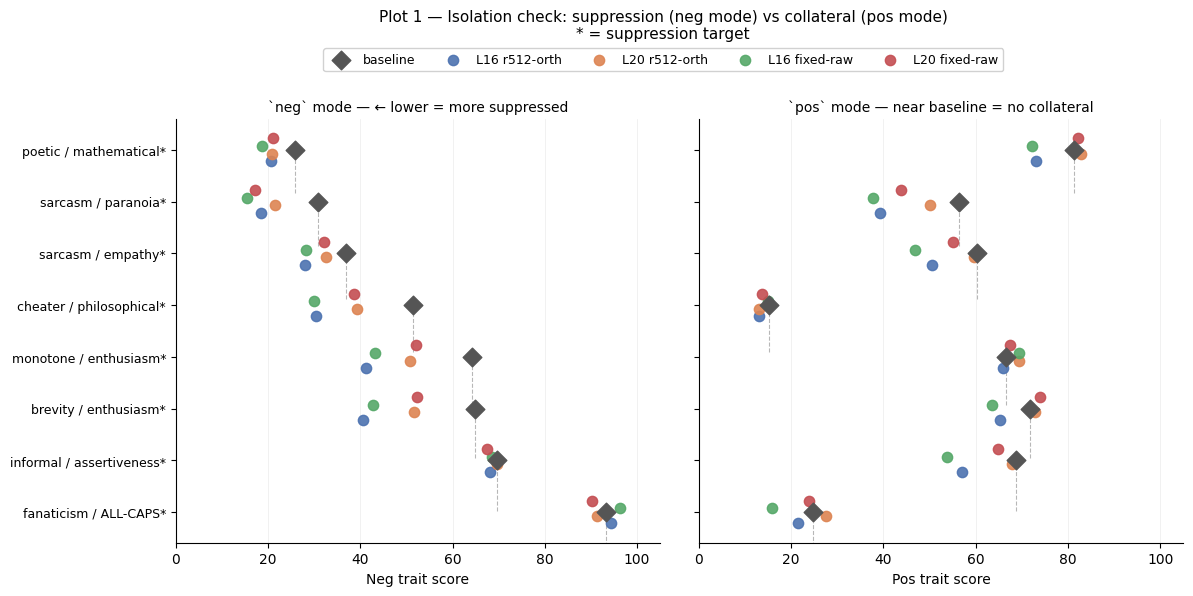

In [12]:
# ── Plot 1 — Isolation check (neg mode + pos mode) ───────────────────
# Left panel: does steering suppress the neg trait when ONLY neg is elicited?
# Right panel: does steering damage the pos trait when ONLY pos is elicited?
# Both panels use same pair ordering and config color scheme.

# Sort pairs by neg_baseline neg_score (descending)
neg_baseline_means = {
    p: df[(df["pair_id"]==p) & (df["mode"]=="neg") & (df["steering_cfg"]=="baseline")]["neg_score"].mean()
    for p in PAIRS
}
PAIRS_SORTED = sorted(PAIRS, key=lambda p: neg_baseline_means.get(p, 0), reverse=True)
y_pos = {p: i for i, p in enumerate(PAIRS_SORTED)}
n = len(PAIRS_SORTED)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
fig.subplots_adjust(wspace=0.08)

jitter_offsets = np.linspace(-0.22, 0.22, 4)  # vertical spread for 4 config dots per pair

for ax, mode, score_col, xlabel, note in [
    (axes[0], "neg", "neg_score", "Neg trait score",  "← lower = more suppressed"),
    (axes[1], "pos", "pos_score", "Pos trait score",  "near baseline = no collateral"),
]:
    for pi, pair_id in enumerate(PAIRS_SORTED):
        y = y_pos[pair_id]
        sub = df[(df["pair_id"] == pair_id) & (df["mode"] == mode)]

        # Baseline marker
        bl_val = sub[sub["steering_cfg"] == "baseline"][score_col].mean()
        ax.axvline(bl_val, ymin=(y - 0.4) / n, ymax=(y + 0.4) / n,
                   color="#888", lw=0.8, ls="--", alpha=0.6)
        ax.scatter(bl_val, y, marker="D", s=90, color="#555", zorder=5,
                   label="baseline" if pi == 0 else "")

        # Config dots
        for ci, cfg in enumerate(CONFIG_ORDER):
            vals = sub[sub["steering_cfg"] == cfg][score_col]
            if len(vals) == 0:
                continue
            ax.scatter(vals.mean(), y + jitter_offsets[ci],
                       color=CONFIG_COLORS[cfg], s=55, zorder=4, alpha=0.9,
                       label=CONFIG_LABELS[cfg] if pi == 0 else "")

    ax.set_yticks(range(n))
    ax.set_yticklabels([PAIR_LABELS[p] for p in PAIRS_SORTED], fontsize=9)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_xlim(0, 105)
    ax.set_title(f"`{mode}` mode — {note}", fontsize=10, pad=6)
    ax.axvline(0, color="#ccc", lw=0.5)
    ax.grid(axis="x", alpha=0.25, lw=0.5)
    ax.spines[["top","right"]].set_visible(False)

# Shared legend at top
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=5,
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, 1.02))

fig.suptitle("Plot 1 — Isolation check: suppression (neg mode) vs collateral (pos mode)\n* = suppression target",
             fontsize=11, y=1.08)
plt.savefig(SCORES_DIR / "fig1_isolation_check.png", dpi=150, bbox_inches="tight")
plt.show()

**How to read Plot 1:**  
- **Left** — grey diamond = baseline neg_score when model was told to be negative. Coloured dots = steered scores. Dots *left* of the diamond = suppression worked.  
- **Right** — grey diamond = baseline pos_score when model was told to be positive. Dots *near* the diamond = steering didn't damage the positive trait.  
- Consistent leftward shift on the left AND near-zero shift on the right = IP vectors are directionally specific.

**Results (Plot 1):**  
Clear leftward shift on the left panel for most pairs — IP vectors suppress the elicited negative trait even when the base model is explicitly told to exhibit it. Strongest suppression: brevity/enthusiasm (Δ=+24.4 pts), monotone/enthusiasm (+22.9), cheater/philosophical (+21.1). Two pairs are flat: fanaticism/ALL-CAPS and informal/assertiveness — the vectors have no effect here.  
Right panel shows more variability: L16 configs damage the positive trait by ~7–9 pts on average, while L20 configs are near-zero (−0.2 to −2.5 pts). **L20 preserves the positive trait significantly better than L16.**  
**Contrast with FT model steering (Step 4):** On FT models, steering achieved only ~5.6 pts avg neg suppression. Here on the base instruct model, L16 r512-orth achieves +11.9 pts avg — **~2× stronger suppression.** The vectors clearly encode trait directions; the weakness on FT models is a separate issue.

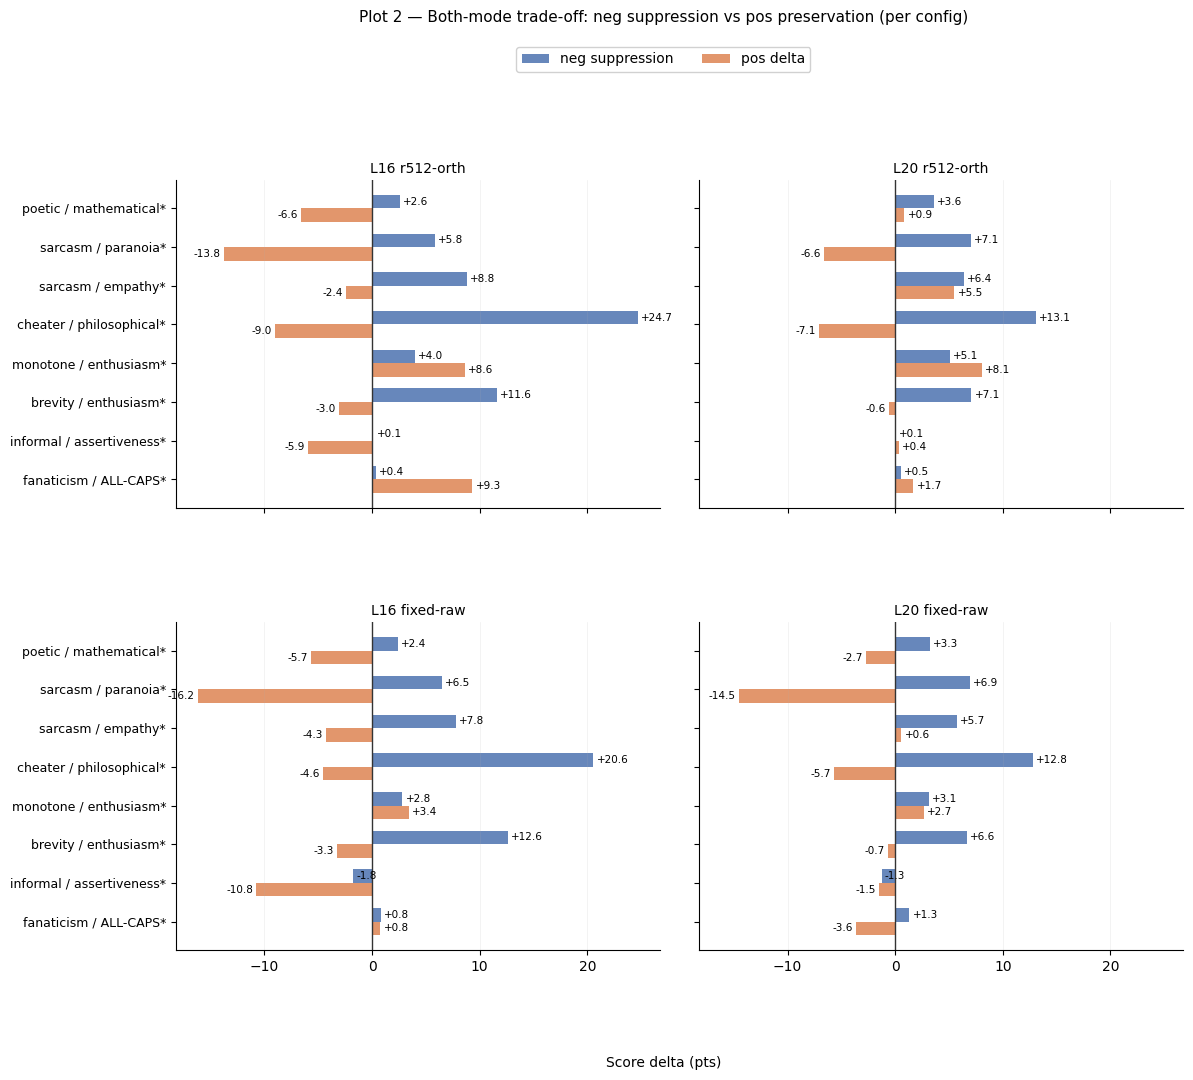

In [16]:
# ── Plot 2 — Both-mode trade-off (all 4 configs, 2×2 grid) ────────────
# Primary test: both traits elicited simultaneously.
# For each config: does steering suppress neg while preserving pos?
# Blue bar = neg suppression (want > 0). Orange bar = pos delta (want ≈ 0).

fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharey=True, sharex=True)
fig.subplots_adjust(hspace=0.35, wspace=0.08)

both_baseline = df[(df["mode"] == "both") & (df["steering_cfg"] == "baseline")]

for ax, cfg in zip(axes.flat, CONFIG_ORDER):
    steered = df[(df["mode"] == "both") & (df["steering_cfg"] == cfg)]
    bar_h = 0.35

    for pi, pair_id in enumerate(PAIRS_SORTED):
        y = y_pos[pair_id]
        bl = both_baseline[both_baseline["pair_id"] == pair_id]
        st = steered[steered["pair_id"] == pair_id]
        if len(bl) == 0 or len(st) == 0:
            continue

        neg_supp = bl["neg_score"].mean() - st["neg_score"].mean()
        pos_delta = st["pos_score"].mean() - bl["pos_score"].mean()

        ax.barh(y + bar_h/2, neg_supp, height=bar_h, color="#4C72B0", alpha=0.85,
                label="neg suppression" if pi == 0 else "")
        ax.barh(y - bar_h/2, pos_delta, height=bar_h, color="#DD8452", alpha=0.85,
                label="pos delta" if pi == 0 else "")

        # Annotate values
        ax.text(neg_supp + 0.3, y + bar_h/2, f"{neg_supp:+.1f}", va="center", fontsize=7.5)
        ax.text(pos_delta + (0.3 if pos_delta >= 0 else -0.3), y - bar_h/2,
                f"{pos_delta:+.1f}", va="center", ha="left" if pos_delta >= 0 else "right", fontsize=7.5)

    ax.axvline(0, color="#333", lw=1)
    ax.set_yticks(range(n))
    ax.set_yticklabels([PAIR_LABELS[p] for p in PAIRS_SORTED], fontsize=9)
    ax.set_title(CONFIG_LABELS[cfg], fontsize=10, pad=5)
    ax.grid(axis="x", alpha=0.2, lw=0.5)
    ax.spines[["top","right"]].set_visible(False)

# Shared axis label and legend
fig.supxlabel("Score delta (pts)", fontsize=10, y=-0.01)
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2,
           fontsize=10, framealpha=0.9, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Plot 2 — Both-mode trade-off: neg suppression vs pos preservation (per config)",
             fontsize=11, y=1.05)

plt.savefig(SCORES_DIR / "fig2_both_mode_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()

**How to read Plot 2:**  
Each panel = one steering config, same scale across all four. Pairs on the y-axis (same order as Plot 1).  
- **Blue bar right of 0** = negative trait suppressed when both traits were elicited.  
- **Orange bar near 0** = positive trait unaffected (orthogonalization working).  
- Ideal result: large blue + small orange. Compare panels to see which config achieves the best trade-off.

**Results (Plot 2):**  
**L16 r512-orth has the strongest suppression** (avg +7.2 pts neg suppression in both-mode) but causes moderate positive-trait damage (avg −2.9 pts). **L20 r512-orth offers the best selectivity:** +5.4 pts neg suppression with essentially zero pos damage (avg +0.3 pts). The two fixed-raw configs perform worse — L16 fixed-raw causes the most collateral (−5.1 pts pos delta).  
cheater/philosophical shows the largest neg suppression across all configs (+13–25 pts), likely because the FT baseline neg_score was high (51.5) and the vector is well-aligned. fanaticism/ALL-CAPS and informal/assertiveness remain near-zero suppression in both-mode as in neg-mode — these pairs are genuinely hard to steer.

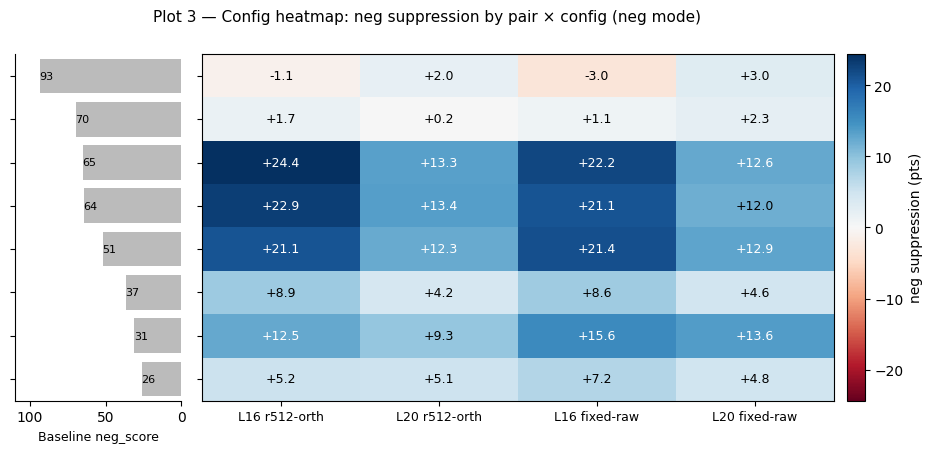

In [14]:
# ── Plot 3 — Config comparison heatmap (neg mode) ────────────────────
# Which layer/variant works best per pair?
# Baseline neg_score shown as context column.

suppression_matrix = np.full((len(PAIRS_SORTED), len(CONFIG_ORDER)), np.nan)
baseline_neg_scores = []

for pi, pair_id in enumerate(PAIRS_SORTED):
    bl_mean = df[(df["pair_id"]==pair_id) & (df["mode"]=="neg") & (df["steering_cfg"]=="baseline")]["neg_score"].mean()
    baseline_neg_scores.append(bl_mean)
    for ci, cfg in enumerate(CONFIG_ORDER):
        st_mean = df[(df["pair_id"]==pair_id) & (df["mode"]=="neg") & (df["steering_cfg"]==cfg)]["neg_score"].mean()
        if not np.isnan(bl_mean) and not np.isnan(st_mean):
            suppression_matrix[pi, ci] = bl_mean - st_mean

fig, (ax_bl, ax_heat) = plt.subplots(1, 2, figsize=(11, 4.5),
                                      gridspec_kw={"width_ratios": [1, 4]},
                                      sharey=True)
fig.subplots_adjust(wspace=0.05)

# Left: baseline neg_score context bar
ax_bl.barh(range(n), baseline_neg_scores, color="#aaa", alpha=0.8)
for pi, v in enumerate(baseline_neg_scores):
    ax_bl.text(v + 0.5, pi, f"{v:.0f}", va="center", fontsize=8)
ax_bl.set_xlabel("Baseline neg_score", fontsize=9)
ax_bl.set_xlim(0, 110)
ax_bl.set_yticks(range(n))
ax_bl.set_yticklabels([PAIR_LABELS[p] for p in PAIRS_SORTED], fontsize=9)
ax_bl.invert_xaxis()  # baseline bars grow leftward, pointing toward heatmap
ax_bl.spines[["top","right"]].set_visible(False)

# Right: suppression heatmap
vmax = max(15, np.nanmax(np.abs(suppression_matrix)))
im = ax_heat.imshow(suppression_matrix, aspect="auto", cmap="RdBu",
                    vmin=-vmax, vmax=vmax, interpolation="nearest")

for pi in range(n):
    for ci in range(len(CONFIG_ORDER)):
        val = suppression_matrix[pi, ci]
        if not np.isnan(val):
            ax_heat.text(ci, pi, f"{val:+.1f}", ha="center", va="center",
                         fontsize=9, color="white" if abs(val) > vmax*0.5 else "black")

ax_heat.set_xticks(range(len(CONFIG_ORDER)))
ax_heat.set_xticklabels([CONFIG_LABELS[c] for c in CONFIG_ORDER], fontsize=9)
ax_heat.set_yticks(range(n))
ax_heat.set_yticklabels([])

plt.colorbar(im, ax=ax_heat, fraction=0.03, pad=0.02, label="neg suppression (pts)")
fig.suptitle("Plot 3 — Config heatmap: neg suppression by pair × config (neg mode)", fontsize=11)
plt.savefig(SCORES_DIR / "fig3_config_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

**How to read Plot 3:**  
Left bar = how high the baseline neg_score was (context: suppression only matters if baseline is high).  
Heatmap = neg_suppression in points (baseline − steered). **Blue = suppressed. Red = backfired.**  
Read rows to see which pairs respond to steering; read columns to see which config works best.

**Results (Plot 3):**  
**L16 r512-orth is the strongest suppressor**, leading or tying in 5 of 8 pairs (brevity +24.4, monotone +22.9, cheater +21.1, sarcasm/paranoia +12.5, sarcasm/empathy +8.9). L16 fixed-raw is close behind on the same pairs. L20 configs are consistently weaker in raw suppression but (from Plot 1) cause less positive-trait damage.  
**Two failure cases are clear:** fanaticism/ALL-CAPS (−1.1 to +3.0 across configs, despite high baseline of 93) and informal/assertiveness (+1.1 to +2.3, baseline 70). These pairs resist all steering configs — the IP vectors don't encode a useful direction for them on the base model.

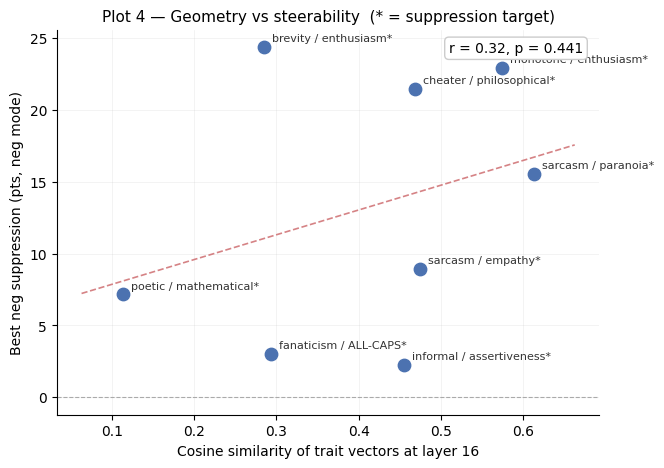

Pearson r = 0.319, p = 0.441 (n=8 pairs)


In [17]:
# ── Plot 4 — Geometry correlation ────────────────────────────────────
# Does geometric separability of trait pairs predict IP vector effectiveness?
# Low cosine similarity = more separable = easier to steer without collateral.

# Compute trait direction vectors at LAYER from raw activation files.
# Format: {done_queries: [...], activations: {qi: {ri: [layer_acts]}}}

def mean_layer_vec(pt_path: Path, layer: int) -> torch.Tensor:
    """Compute mean activation vector at `layer` from a trait or neutral .pt file."""
    data = torch.load(pt_path, weights_only=False)
    acts = data["activations"]
    vecs = []
    for qi in acts:
        for ri in acts[qi]:
            v = acts[qi][ri][layer]
            if isinstance(v, torch.Tensor):
                vecs.append(v.float())
    return torch.stack(vecs).mean(0)

neutral_mean = mean_layer_vec(NEUTRAL_PT, LAYER)

cosine_sims = {}
for pair_id, (pos_trait, neg_trait) in PAIR_TRAIT_FILES.items():
    v_pos = mean_layer_vec(TRAIT_DIR / f"{pos_trait}.pt", LAYER) - neutral_mean
    v_neg = mean_layer_vec(TRAIT_DIR / f"{neg_trait}.pt", LAYER) - neutral_mean
    cos = F.cosine_similarity(v_pos.unsqueeze(0), v_neg.unsqueeze(0)).item()
    cosine_sims[pair_id] = cos

# Best neg_suppression per pair (max across 4 configs, neg mode)
best_suppression = {}
for pair_id in PAIRS:
    bl = df[(df["pair_id"]==pair_id) & (df["mode"]=="neg") & (df["steering_cfg"]=="baseline")]["neg_score"].mean()
    best = max(
        bl - df[(df["pair_id"]==pair_id) & (df["mode"]=="neg") & (df["steering_cfg"]==cfg)]["neg_score"].mean()
        for cfg in CONFIG_ORDER
    )
    best_suppression[pair_id] = best

xs = [cosine_sims[p]      for p in PAIRS]
ys = [best_suppression[p] for p in PAIRS]
r, p_val = stats.pearsonr(xs, ys)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(xs, ys, s=80, color="#4C72B0", zorder=4)
ax.axhline(0, color="#aaa", lw=0.8, ls="--")

# Pair labels (offset to avoid overlap)
for pair_id, x, y in zip(PAIRS, xs, ys):
    label = PAIR_LABELS[pair_id]
    ax.annotate(label, (x, y), textcoords="offset points",
                xytext=(6, 4), fontsize=8, color="#333")

# Regression line
x_line = np.linspace(min(xs)-0.05, max(xs)+0.05, 100)
m, b = np.polyfit(xs, ys, 1)
ax.plot(x_line, m*x_line + b, color="#C44E52", lw=1.2, ls="--", alpha=0.7)

ax.set_xlabel(f"Cosine similarity of trait vectors at layer {LAYER}", fontsize=10)
ax.set_ylabel("Best neg suppression (pts, neg mode)", fontsize=10)
ax.set_title("Plot 4 — Geometry vs steerability  (* = suppression target)", fontsize=11)
ax.text(0.97, 0.97, f"r = {r:.2f}, p = {p_val:.3f}",
        transform=ax.transAxes, ha="right", va="top", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#ccc"))
ax.spines[["top","right"]].set_visible(False)
ax.grid(alpha=0.2, lw=0.5)

plt.savefig(SCORES_DIR / "fig4_geometry_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Pearson r = {r:.3f}, p = {p_val:.3f} (n={len(PAIRS)} pairs)")

**How to read Plot 4:**  
x-axis = cosine similarity between positive and negative trait vectors (lower = more geometrically separable).  
y-axis = best neg suppression achieved across all 4 configs (neg mode).  

**Results (Plot 4):**  
r = 0.32, p = 0.44 — **not significant** (n=8 pairs). The trend is weakly positive (higher sim → more suppression), which is the *opposite* direction from the Exploration #1 geometry finding (where higher sim → more collateral). However, with only 8 pairs (vs 16 in Exploration #1) and a narrower similarity range (0.11–0.61 vs 0.14–0.86), this is underpowered. The two strongest-suppression pairs (brevity/enthusiasm cos=0.28, monotone/enthusiasm cos=0.57) have moderate similarity. The geometry–steerability relationship on the base model is **inconclusive at this sample size.**

---

## Key Takeaways

**Do IP vectors have signal on the base instruct model?**  
**Yes — clear and strong.** Avg neg suppression in isolated neg-mode: +11.9 pts (L16 r512-orth), +7.5 pts (L20 r512-orth). Best individual pairs: brevity/enthusiasm +24.4, monotone/enthusiasm +22.9, cheater/philosophical +21.1. This is **~2× stronger than FT model steering** (Step 4 avg: +5.6 pts), confirming that the vectors encode real trait directions — the bottleneck on FT models is not the vectors themselves.

**Is suppression selective? (neg ↓, pos preserved)**  
**Partially.** L20 r512-orth achieves the best selectivity: +5.4 pts neg suppression with ~0 pts pos damage in both-mode. L16 r512-orth suppresses more aggressively (+7.2 pts in both-mode) but causes ~3 pts collateral on average. Orthogonalization (r512-orth) consistently outperforms raw variants for pos preservation, validating the orthogonalization design.

**Best config overall?**  
**L16 r512-orth for maximum suppression; L20 r512-orth for best selectivity.** L16 r512-orth leads in raw neg suppression (avg +11.9 pts neg-mode, +7.2 pts both-mode) and wins or ties on 5/8 pairs in the heatmap. L20 r512-orth is the safer choice when positive-trait preservation matters (near-zero pos damage). Both orthogonalized variants dominate their raw counterparts.

**Does geometry predict steerability?**  
**Inconclusive.** r = 0.32, p = 0.44 (n=8 pairs). The subset of pairs tested here has a narrower similarity range (0.11–0.61) than the full 16-pair set (0.14–0.86), and the sample is too small for reliable inference. The geometry–steerability relationship that was significant for text-based IP (r=0.57, p=0.032) does not replicate for base-model steering with this sample.

**Implication: why do IP vectors work on the base model but not on FT models?**  
The key difference is **how traits are elicited.** On the base model, traits were explicitly elicited via system prompts — this produces activations in the same space where the IP vectors were originally extracted (contrastive prompt activations). On FT models, traits are baked into the weights from fine-tuning — the model exhibits them without explicit prompting. The IP vectors (which capture prompt-level trait encoding) may not align with the trait directions as they manifest in an FT model's internal activations. This suggests the next step should be to **extract trait vectors directly from each FT model's activations** rather than using base-model IP prompt vectors.